In [89]:
words = open('names.txt', 'r').read().splitlines()

words[:3]

['emma', 'olivia', 'ava']

In [90]:
len(words)

32033

In [91]:
min(len(w) for w in words)

2

In [92]:
max(len(w) for w in words)

15

In [93]:
for w in words[:1]:
    chs = ['<S>'] + list(w) + ['<E>']
    for (ch1, ch2) in zip(chs, chs[1:]):
        print(ch1, ch2)

<S> e
e m
m m
m a
a <E>


In [94]:
b = {}
for w in words[:3]:
    chs = ['<S>'] + list(w) + ['<E>']
    for ch1, ch2 in zip(chs, chs[1:]):
        bigram = (ch1, ch2) # packages the two character as a tuple 
        b[bigram] = b.get(bigram, 0) + 1 # write the new count of the bigram back into the dictionary 

b

# .get method return the "value" of a "key" which it takes as a paramter - see example below 

{('<S>', 'e'): 1,
 ('e', 'm'): 1,
 ('m', 'm'): 1,
 ('m', 'a'): 1,
 ('a', '<E>'): 3,
 ('<S>', 'o'): 1,
 ('o', 'l'): 1,
 ('l', 'i'): 1,
 ('i', 'v'): 1,
 ('v', 'i'): 1,
 ('i', 'a'): 1,
 ('<S>', 'a'): 1,
 ('a', 'v'): 1,
 ('v', 'a'): 1}

In [95]:
d = {'a': 5, 'b': 2}
d.get("x", 0) # returns 0
d.get("x") # return None as default 
d.get("a") # returns 5 
d.get("b") # returns 2 

2

In [96]:
sorted(b.items(), key = lambda kv: -kv[1])

[(('a', '<E>'), 3),
 (('<S>', 'e'), 1),
 (('e', 'm'), 1),
 (('m', 'm'), 1),
 (('m', 'a'), 1),
 (('<S>', 'o'), 1),
 (('o', 'l'), 1),
 (('l', 'i'), 1),
 (('i', 'v'), 1),
 (('v', 'i'), 1),
 (('i', 'a'), 1),
 (('<S>', 'a'), 1),
 (('a', 'v'), 1),
 (('v', 'a'), 1)]

In [97]:
# Store bigrams in a 2-dimensional array w
# Each row will be the first character and the column the second character 
# Each entry in the 2-dimensional array tells us how often a particular bigram occurs (first character following second character)

import torch 

In [98]:
a = torch.zeros((3, 5), dtype=torch.int32)
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [99]:
a.dtype

torch.int32

In [100]:
a[1, 3] += 1 

In [101]:
a

tensor([[0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0],
        [0, 0, 0, 0, 0]], dtype=torch.int32)

In [102]:
words[:10] # list of the first ten names 

['emma',
 'olivia',
 'ava',
 'isabella',
 'sophia',
 'charlotte',
 'mia',
 'amelia',
 'harper',
 'evelyn']

In [103]:
a = ''.join(words) # joins all the words (names) into one huge massive string 
a

'...'

In [104]:
# We need to get all the unique character in the dataset of number which is simply all 26 character of the alphabet 
a = set(''.join(words)) # gets all the unique characters from the huge string 
chars = sorted(list(set(''.join(words)))) # we want it as a sorted list 
chars

['a',
 'b',
 'c',
 'd',
 'e',
 'f',
 'g',
 'h',
 'i',
 'j',
 'k',
 'l',
 'm',
 'n',
 'o',
 'p',
 'q',
 'r',
 's',
 't',
 'u',
 'v',
 'w',
 'x',
 'y',
 'z']

In [118]:
# Because computers only understand numbers, we need to map each character to a number 
# So we need a look up table for 
# stoi - string to interger
# itos = integer to string 

stoi = {s:i+1 for i, s in enumerate(chars)}
stoi["."] = 0
stoi

{'a': 1,
 'b': 2,
 'c': 3,
 'd': 4,
 'e': 5,
 'f': 6,
 'g': 7,
 'h': 8,
 'i': 9,
 'j': 10,
 'k': 11,
 'l': 12,
 'm': 13,
 'n': 14,
 'o': 15,
 'p': 16,
 'q': 17,
 'r': 18,
 's': 19,
 't': 20,
 'u': 21,
 'v': 22,
 'w': 23,
 'x': 24,
 'y': 25,
 'z': 26,
 '.': 0}

In [119]:
# integer to string 
# get the reverse of stoi 
itos = {i: s for s, i in stoi.items()}
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [120]:
# Choice of the size of 2-D array to use 
# Because we have 26 letters of the alphabet and then plus two special characters <S> and <E>, 
# We use a 28x28 2-D array 

# So, we will be storing the counts of how each character follows another in a 28x28 2D array 
N = torch.zeros((27, 27), dtype=torch.int32)

In [121]:
# Store in N 
# N 
for w in words:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] # converts ch1 to its integer's index (example: b -> 1)
        ix2 = stoi[ch2] # converts ch2 to its integer's index (example: z -> 25)
        # remember N is a 2-dimensional array (matrix): ix1 is the row index and ix2 is the column index.
        N[ix1, ix2] += 1 # increments by 1 each time ix1 follows ix2 

In [122]:
# use matplotlib to visualize N 

import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(N, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, N[i, j].item(), ha="center", va="top", color='gray')
plt.axis('off');

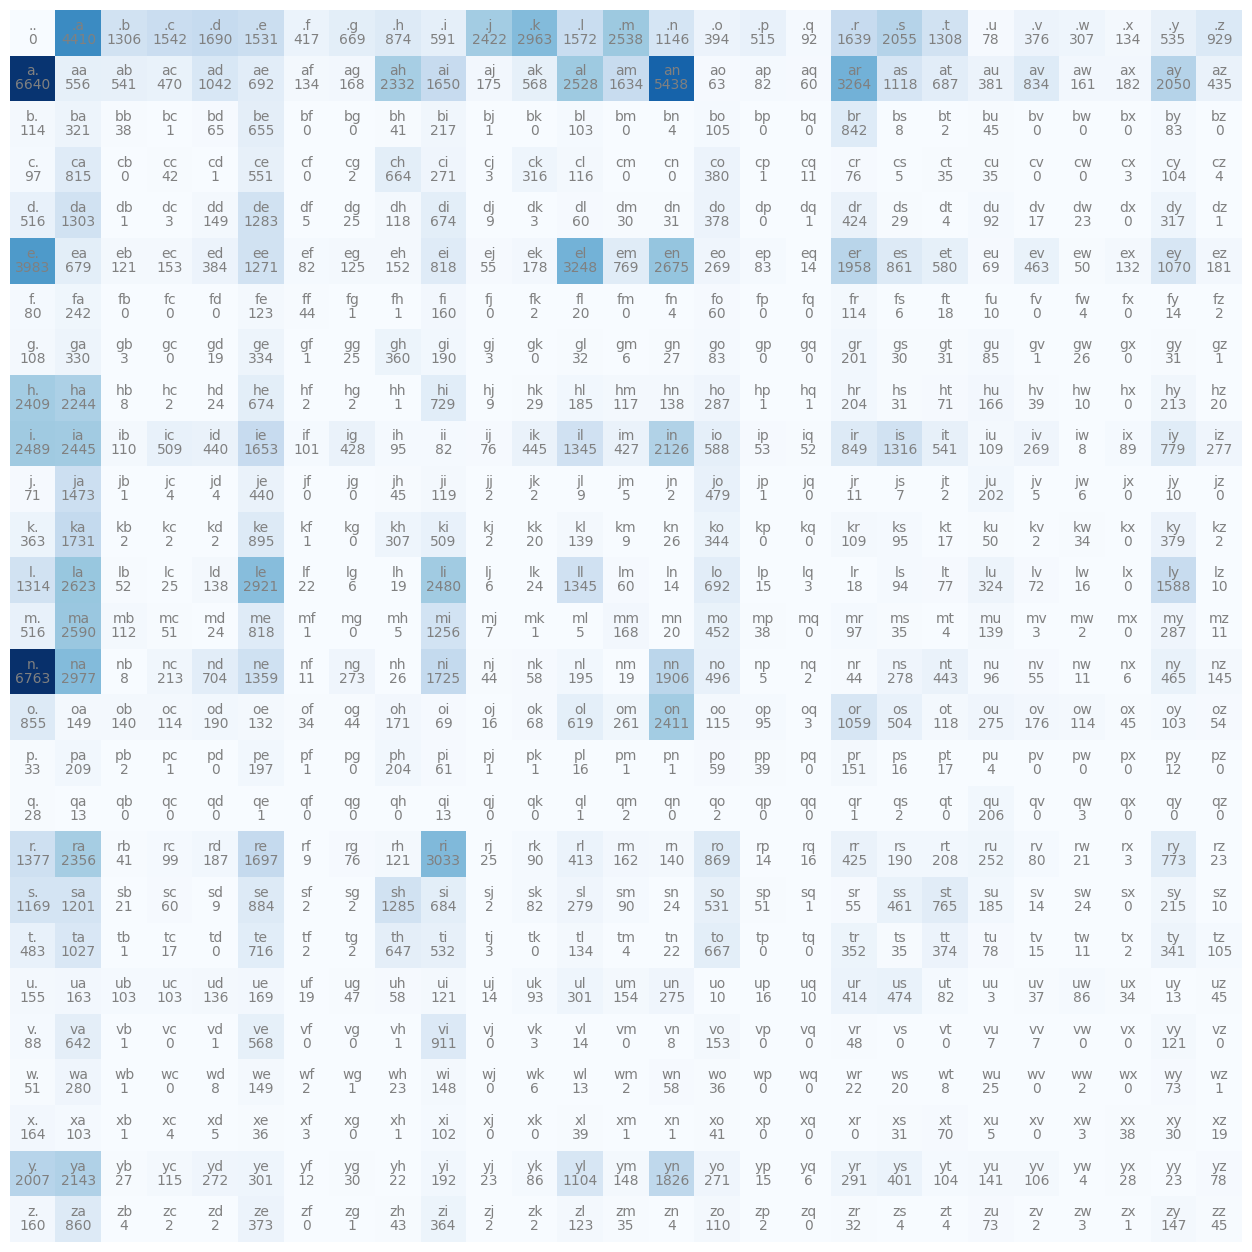

In [ ]:
plt.show()

# Shows the counts array of the entire name dataset 
# First row shows the starting character counts 
# First columns shows the ending character counts 
# Thw rows and columns inbetween shows the counts of letters that follow each other 

# This array has all the information for us to actually sample from 
# So we are going to sample from this after converting the counts to a probability distribution 

In [110]:
N[3, 3]

tensor(149, dtype=torch.int32)

In [ ]:
# Convert the counts of the first row to probabilities by normalizing it 
N[0] # grab the first row 

p = N[0].float() # convert the integer counts to float numbers
p = p / p.sum()
p # This is the probability distribution we want to sample from 

tensor([0.0000, 0.1377, 0.0408, 0.0481, 0.0528, 0.0478, 0.0130, 0.0209, 0.0273,
        0.0184, 0.0756, 0.0925, 0.0491, 0.0792, 0.0358, 0.0123, 0.0161, 0.0029,
        0.0512, 0.0642, 0.0408, 0.0024, 0.0117, 0.0096, 0.0042, 0.0167, 0.0290])

In [138]:
# Use a seed generator so that we can the same random values that kaparthy got 
g = torch.Generator().manual_seed(2147483647)
samples = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item()
itos[samples]

'l'

In [144]:
g = torch.Generator().manual_seed(2147483647)

# The flow of the loop is 
# -- First sample from row 0 
# -- Use the sampled index as the next row to sample from 
# -- Repeat until you sample an index 0 character 

for i in range(10): # sample 10 names 
    out = []

    ix = 0 # Index of the first row - The first sample has to come from the first row 
    while True:
        p = N[ix].float()  # convert ints counts to floats 
        p = p / p.sum() # Normalize that row which converts it to probabilities
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # sample a character from that row's probability distribution 
        out.append(itos[ix])
        if ix == 0: # if the sampled character is the "End or start token" (.)
            break # break the while loop 

    print(''.join(out))

junide.
janasah.
p.
cony.
a.
nn.
kohin.
tolian.
juee.
ksahnaauranilevias.


In [151]:
# We want to convert the whole counts array to probabilities by normalizing all the rows silmultaneously and in parallel 

# P is a copy of the N counts array but the counts are converted to floats 
P = N.float()

P.shape 

torch.Size([27, 27])

In [157]:
# Sum total counts accros rows 
# Keep dim = True makes sure we don't squeeze out the output dim to just [27]. We want it to be explicitly [27, 1]

# passing 1 in that sum function means we want to sum across the rows 
# if we pass 0, then we will sum across columns 
P /= P.sum(1, keepdim=True)

In [158]:
# Check if normalization worked 
# Output should be 1 
P[1].sum() 

tensor(1.)

In [160]:
g = torch.Generator().manual_seed(2147483647)

# The flow of the loop is 
# -- First sample from row 0 
# -- Use the sampled index as the next row to sample from 
# -- Repeat until you sample an index 0 character 

for i in range(10): # sample 10 names 
    out = []

    ix = 0 # Index of the first row - The first sample has to come from the first row 
    while True:
        p = P[ix] # We are using the normalized counts array here 
        ix = torch.multinomial(p, num_samples=1, replacement=True, generator=g).item() # sample a character from that row's probability distribution 
        out.append(itos[ix])
        if ix == 0: # if the sampled character is the "End or start token" (.)
            break # break the while loop 

    print(''.join(out))

junide.
janasah.
p.
cony.
a.
nn.
kohin.
tolian.
juee.
ksahnaauranilevias.


In [ ]:
for w in words[:3]:
    chs = ['.'] + list(w) + ['.']
    for ch1, ch2 in zip(chs, chs[1:]):
        ix1 = stoi[ch1] 
        ix2 = stoi[ch2] 
        prob = P[ix1, ix2] # see the probability of each bigram 
        print(f"{ch1}{ch2}: {prob}")

.e
em
mm
ma
a.
.o
ol
li
iv
vi
ia
a.
.a
av
va
a.


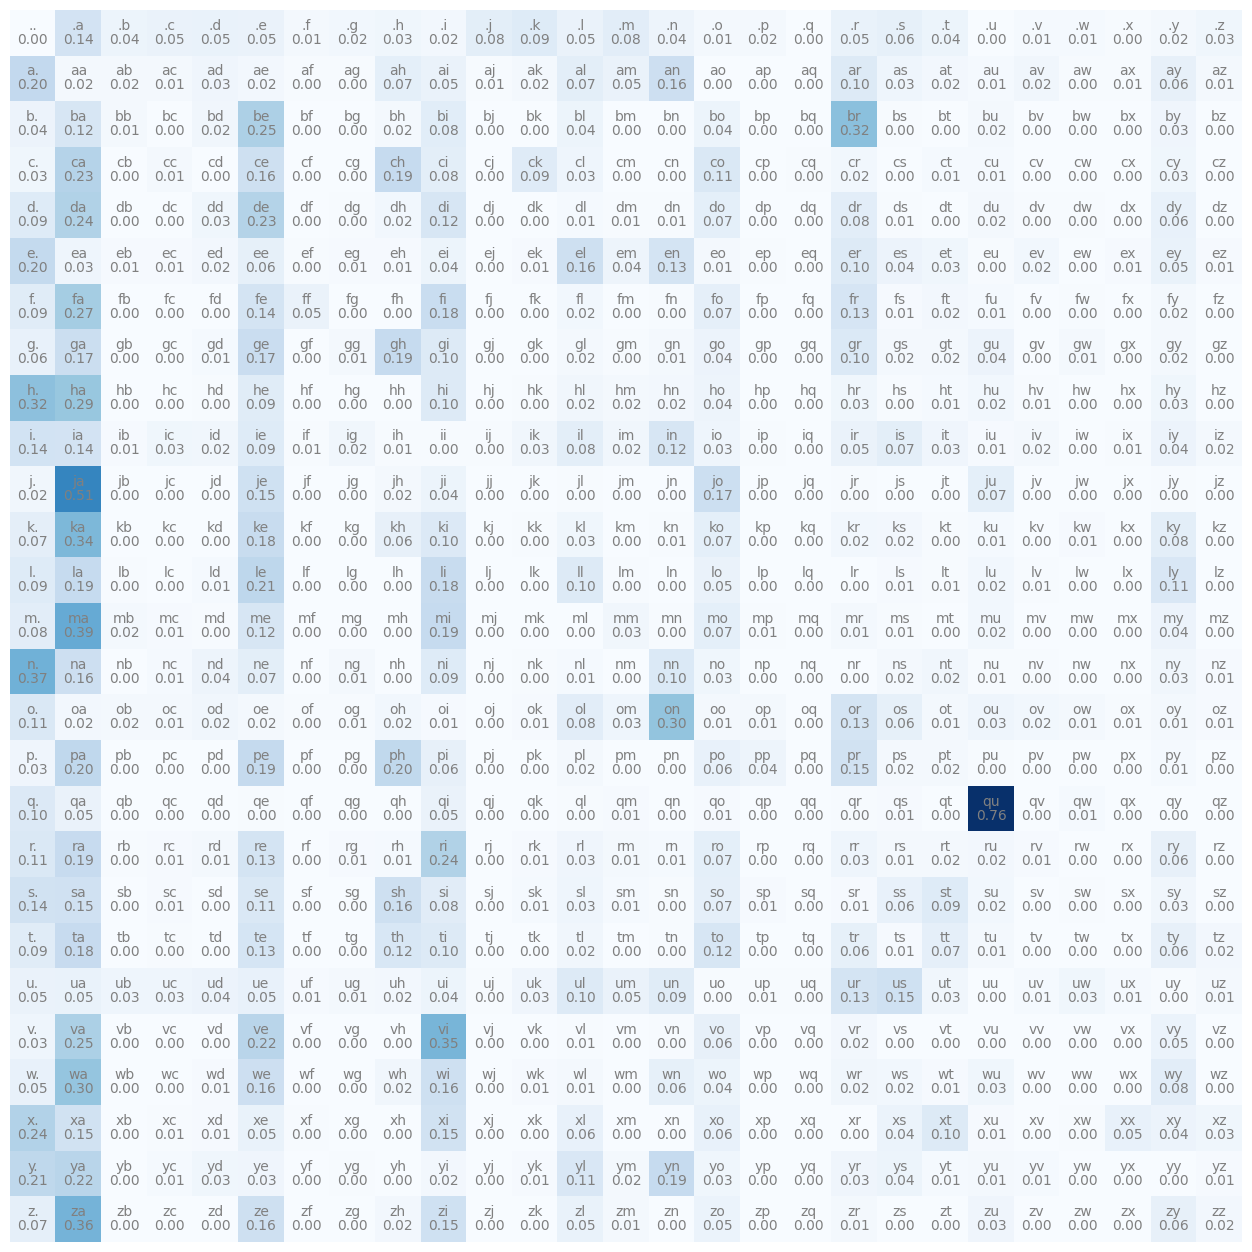

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

plt.figure(figsize=(16,16))
plt.imshow(P, cmap='Blues')
for i in range(27):
    for j in range(27):
        chstr = itos[i] + itos[j]
        plt.text(j, i, chstr, ha="center", va="bottom", color='gray')
        plt.text(j, i, f"{P[i, j].item():.2f}", ha="center", va="top", color='gray')
plt.axis('off');

plt.show() # This Shows the probability distribution matrix

In [ ]:
P[0].sum() # across row 0 from the matrix above, it sums to 1 

tensor(1.)